In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/ybifoundation/Dataset/main/Salary%20Data.csv"

dataset = pd.read_csv(url)

print(dataset.head(40))

    Experience Years  Salary
0                1.1   39343
1                1.2   42774
2                1.3   46205
3                1.5   37731
4                2.0   43525
5                2.2   39891
6                2.5   48266
7                2.9   56642
8                3.0   60150
9                3.2   54445
10               3.2   64445
11               3.5   60000
12               3.7   57189
13               3.8   60200
14               3.9   63218
15               4.0   55794
16               4.0   56957
17               4.1   57081
18               4.3   59095
19               4.5   61111
20               4.7   64500
21               4.9   67938
22               5.1   66029
23               5.3   83088
24               5.5   82200
25               5.9   81363
26               6.0   93940
27               6.2   91000
28               6.5   90000
29               6.8   91738
30               7.1   98273
31               7.9  101302
32               8.2  113812
33            

In [2]:
print(dataset.info())

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Experience Years  40 non-null     float64
 1   Salary            40 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 772.0 bytes
None


In [3]:
print(dataset.describe())

       Experience Years         Salary
count         40.000000      40.000000
mean           5.152500   74743.625000
std            2.663715   25947.122885
min            1.100000   37731.000000
25%            3.200000   56878.250000
50%            4.600000   64472.500000
75%            6.875000   95023.250000
max           10.500000  122391.000000


In [4]:
print(dataset.isnull().sum())

Experience Years    0
Salary              0
dtype: int64


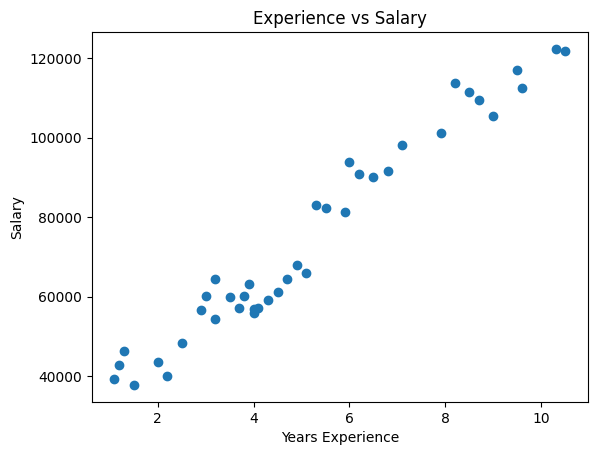

In [5]:
plt.scatter(dataset['Experience Years'], dataset['Salary'])
plt.xlabel('Years Experience')
plt.ylabel('Salary')
plt.title('Experience vs Salary')
plt.show()

In [6]:
X = dataset.iloc[:, :-1].values
Y = dataset.iloc[:, -1].values
# print(X,Y)

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=0
)
# print(X_train, y_train)
# print(X_test, y_test)

In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
y_pred = model.predict(X_test)

print(y_pred)

[74625.31383782 70821.36597832 82233.20955681 45144.71792673
 56556.56150521 64164.4572242  87939.13134605 59409.52239984]


In [10]:
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)

print("R2 Score:", score)

R2 Score: 0.8260957382965146


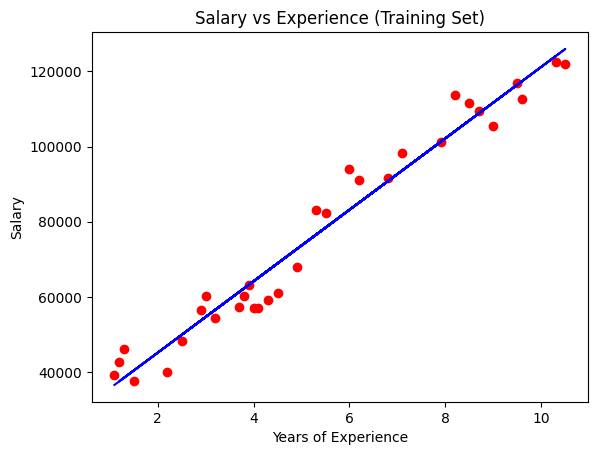

In [11]:
plt.scatter(X_train, y_train, color='red')

plt.plot(X_train, model.predict(X_train), color='blue')

plt.title('Salary vs Experience (Training Set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')

plt.show()

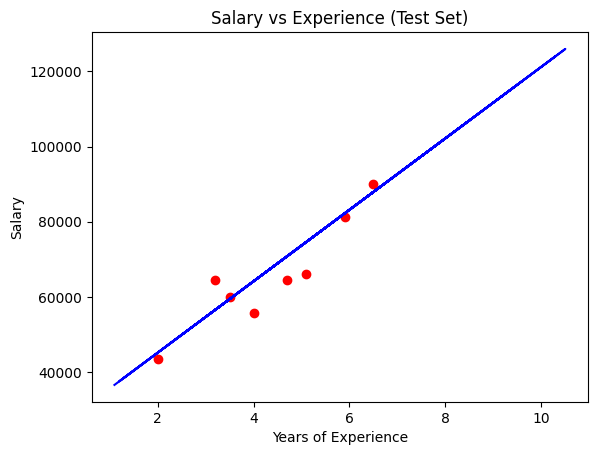

In [12]:
plt.scatter(X_test, y_test, color='red')

plt.plot(X_train, model.predict(X_train), color='blue')

plt.title('Salary vs Experience (Test Set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')

plt.show()